🏡 Nashville Housing Data Cleaning & EDA Project

📌 Introduction

In this project, I will clean and explore the Nashville Housing dataset (2013–2016).
The goal is to:

Clean messy data (duplicates, missing values, inconsistent formats)

Perform exploratory data analysis (EDA)

Generate insights with visualizations

🔹 Step 1: Import Libraries & Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/kaggle/input/nashville-housing-data/Nashville_housing_data_2013_2016.csv")

# Quick overview
print(df.shape)
df.head()



(56636, 31)


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,Unnamed: 0.1,Unnamed: 0,Parcel ID,Land Use,Property Address,Suite/ Condo #,Property City,Sale Date,Sale Price,Legal Reference,...,Building Value,Total Value,Finished Area,Foundation Type,Year Built,Exterior Wall,Grade,Bedrooms,Full Bath,Half Bath
0,0,0,105 03 0D 008.00,RESIDENTIAL CONDO,1208 3RD AVE S,8,NASHVILLE,2013-01-24,132000,20130128-0008725,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,105 11 0 080.00,SINGLE FAMILY,1802 STEWART PL,NaN,NASHVILLE,2013-01-11,191500,20130118-0006337,...,134400.0,168300.0,1149.00000,PT BSMT,1941.0,BRICK,C,2.0,1.0,0.0
2,2,2,118 03 0 130.00,SINGLE FAMILY,2761 ROSEDALE PL,NaN,NASHVILLE,2013-01-18,202000,20130124-0008033,...,157800.0,191800.0,2090.82495,SLAB,2000.0,BRICK/FRAME,C,3.0,2.0,1.0
3,3,3,119 01 0 479.00,SINGLE FAMILY,224 PEACHTREE ST,NaN,NASHVILLE,2013-01-18,32000,20130128-0008863,...,243700.0,268700.0,2145.60001,FULL BSMT,1948.0,BRICK/FRAME,B,4.0,2.0,0.0
4,4,4,119 05 0 186.00,SINGLE FAMILY,316 LUTIE ST,NaN,NASHVILLE,2013-01-23,102000,20130131-0009929,...,138100.0,164800.0,1969.00000,CRAWL,1910.0,FRAME,C,2.0,1.0,0.0


🔹 Step 2: Clean Column Names

In [2]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(df.columns.tolist())


['unnamed:_0.1', 'unnamed:_0', 'parcel_id', 'land_use', 'property_address', 'suite/_condo___#', 'property_city', 'sale_date', 'sale_price', 'legal_reference', 'sold_as_vacant', 'multiple_parcels_involved_in_sale', 'owner_name', 'address', 'city', 'state', 'acreage', 'tax_district', 'neighborhood', 'image', 'land_value', 'building_value', 'total_value', 'finished_area', 'foundation_type', 'year_built', 'exterior_wall', 'grade', 'bedrooms', 'full_bath', 'half_bath']


🔹 Step 3: Remove Duplicates

In [3]:
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicates after:", df.duplicated().sum())


Duplicates before: 0
Duplicates after: 0


🔹 Step 4: Fix Date Columns

In [4]:
df['sale_date'] = pd.to_datetime(df['sale_date'], errors='coerce')
print(df['sale_date'].head())


0   2013-01-24
1   2013-01-11
2   2013-01-18
3   2013-01-18
4   2013-01-23
Name: sale_date, dtype: datetime64[ns]


🔹 Step 5: Clean Categorical Columns

In [5]:
df['sold_as_vacant'] = df['sold_as_vacant'].replace({
    'Y': 'Yes', 'N': 'No'
})
print(df['sold_as_vacant'].value_counts())


sold_as_vacant
No     51741
Yes     4895
Name: count, dtype: int64


🔹 Step 6: Handle Missing Values

In [6]:
df.isnull().sum().sort_values(ascending=False).head(10)


suite/_condo___#    50527
half_bath           32490
bedrooms            32477
foundation_type     32472
grade               32471
exterior_wall       32471
year_built          32471
finished_area       32470
full_bath           32359
owner_name          31375
dtype: int64

📊 Step 7: Exploratory Data Analysis (EDA)

1. Distribution of Sale Prices

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


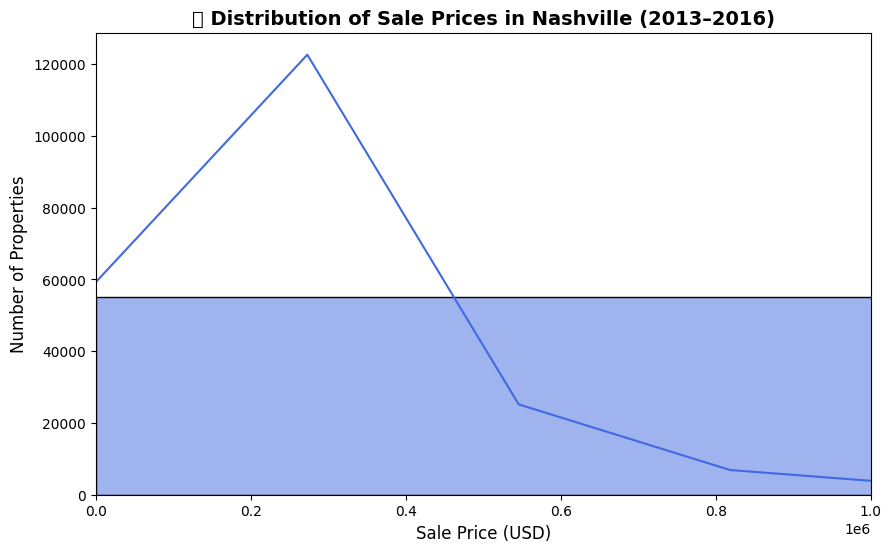

In [7]:
plt.figure(figsize=(10,6))
sns.histplot(df['sale_price'], bins=50, kde=True, color="royalblue")

plt.title("🏠 Distribution of Sale Prices in Nashville (2013–2016)", fontsize=14, weight='bold')
plt.xlabel("Sale Price (USD)", fontsize=12)
plt.ylabel("Number of Properties", fontsize=12)

# Limit x-axis (optional, helps ignore extreme outliers)
plt.xlim(0, 1_000_000)

plt.show()



2. Sales Over Time

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


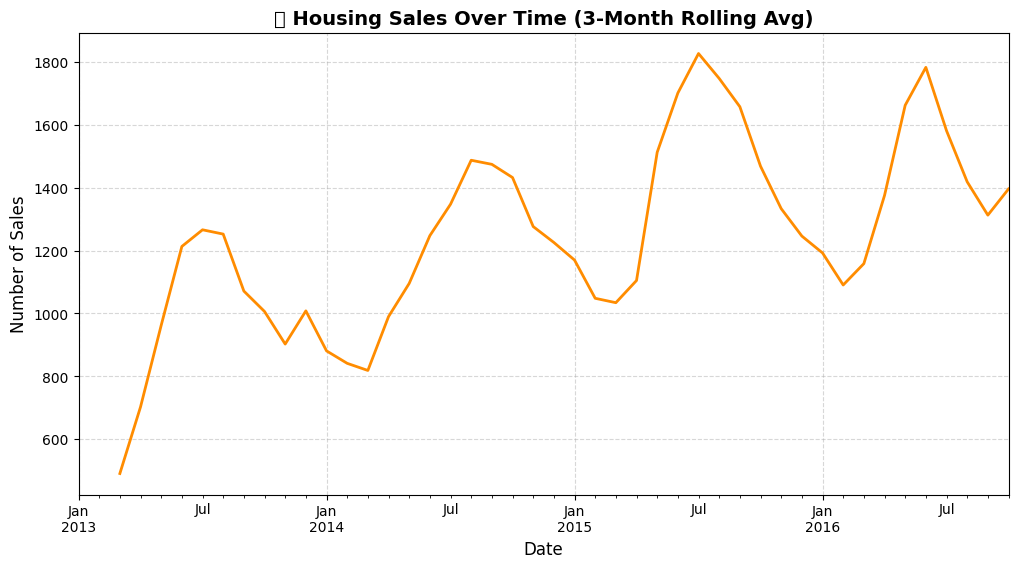

In [8]:
sales_over_time = df.groupby(df['sale_date'].dt.to_period("M")).size()
sales_over_time.index = sales_over_time.index.to_timestamp()

plt.figure(figsize=(12,6))
sales_over_time.rolling(3).mean().plot(color="darkorange", linewidth=2)

plt.title("📈 Housing Sales Over Time (3-Month Rolling Avg)", fontsize=14, weight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Number of Sales", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()


3. Sale Price by Property Type

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


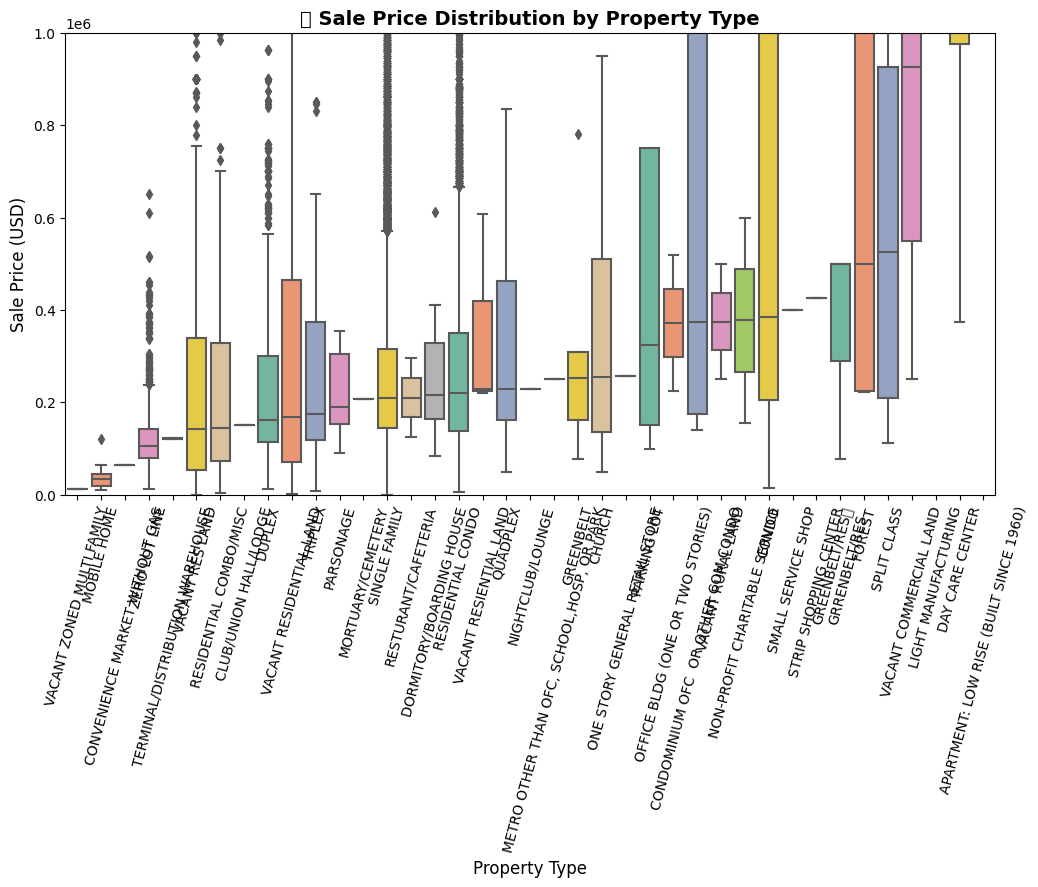

In [9]:
plt.figure(figsize=(12,6))
order = df.groupby("land_use")["sale_price"].median().sort_values().index

sns.boxplot(
    x="land_use", y="sale_price", data=df,
    order=order, palette="Set2"
)

plt.title("💰 Sale Price Distribution by Property Type", fontsize=14, weight='bold')
plt.xlabel("Property Type", fontsize=12)
plt.ylabel("Sale Price (USD)", fontsize=12)
plt.xticks(rotation=75)

plt.ylim(0, 1_000_000)  # keep visualization readable
plt.show()


4. Vacant vs Non-Vacant Sales

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127959 (\N{BUILDING CONSTRUCTION}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


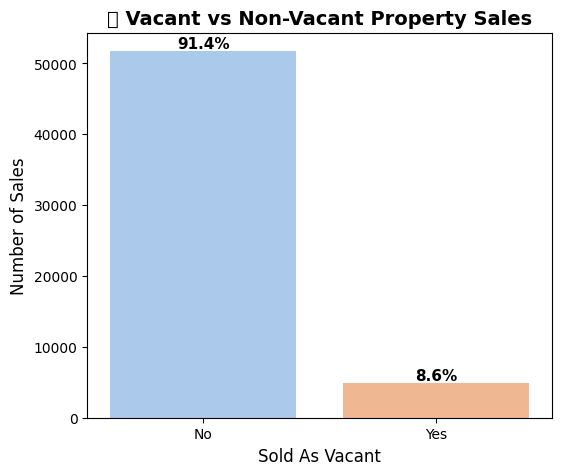

In [10]:
plt.figure(figsize=(6,5))
ax = sns.countplot(x="sold_as_vacant", data=df, palette="pastel")

plt.title("🏗️ Vacant vs Non-Vacant Property Sales", fontsize=14, weight='bold')
plt.xlabel("Sold As Vacant", fontsize=12)
plt.ylabel("Number of Sales", fontsize=12)

# Add % labels on top of bars
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage,
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color="black", weight='bold')

plt.show()


🔹 Step 8: Export Cleaned Data

In [11]:
df.to_csv("nashville_housing_cleaned.csv", index=False)



✅ Conclusion

Cleaned dataset with duplicates removed and standardized categories

Converted sale dates for time analysis

Visualized sales distribution, time trends, property types, and vacancy status

Exported cleaned dataset for further modeling

This project demonstrates data cleaning, exploratory analysis, and visualization — essential skills for any data analyst role.